## Goal:
Test whether Astrocyte_2 is enriched for Alzheimer’s disease–associated risk gene programs.

## Load Data

In [5]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, spearmanr

adata = sc.read_h5ad("../data/processed/brain_non_neuronal_50k_annotated_umap.h5ad")
adata.obs.head()

,cell_barcode,library_label,anatomical_division_label,leiden,cell_type,AD_support_score,Neuroprotective Support Score
cell_label,,,,,,,
10X385_4:GCATTAGCATCCAACA,GCATTAGCATCCAACA,LKTX_210818_04_D01,Basal nuclei,5,Pericyte,8.613595,8.613595
10X229_5:TCTGCCATCTCGGTCT,TCTGCCATCTCGGTCT,LKTX_191010_01_E01,Hippocampus,4,Astrocyte,-2.493847,-2.493847
10X206_8:TTCAATCAGAGCTGAC,TTCAATCAGAGCTGAC,LKTX_190620_02_H01,Hippocampus,2,Unknown,-2.433950,-2.433950
10X356_2:ACTCTCGTCCGCGGAT,ACTCTCGTCCGCGGAT,LKTX_210519_02_B01,Cerebellum,2,Unknown,0.447153,0.447153
10X386_4:GAATCGTAGGGTACGT,GAATCGTAGGGTACGT,LKTX_210825_01_D01,Pons,3,Endothelial,-1.043953,-1.043953


## AD support score violin across all cell types

C:\Users\dtquocbao\AppData\Local\Temp\ipykernel_26184\3417285336.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


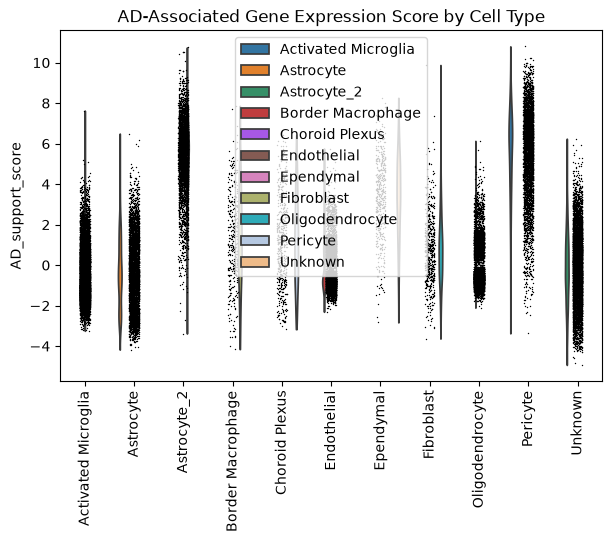

In [6]:
ax = sc.pl.violin(
    adata,
    keys="AD_support_score",
    groupby="cell_type",
    rotation=90,
    show=False
)
plt.title("AD-Associated Gene Expression Score by Cell Type")
plt.tight_layout()
plt.show()

## UMAP colored by AD support score

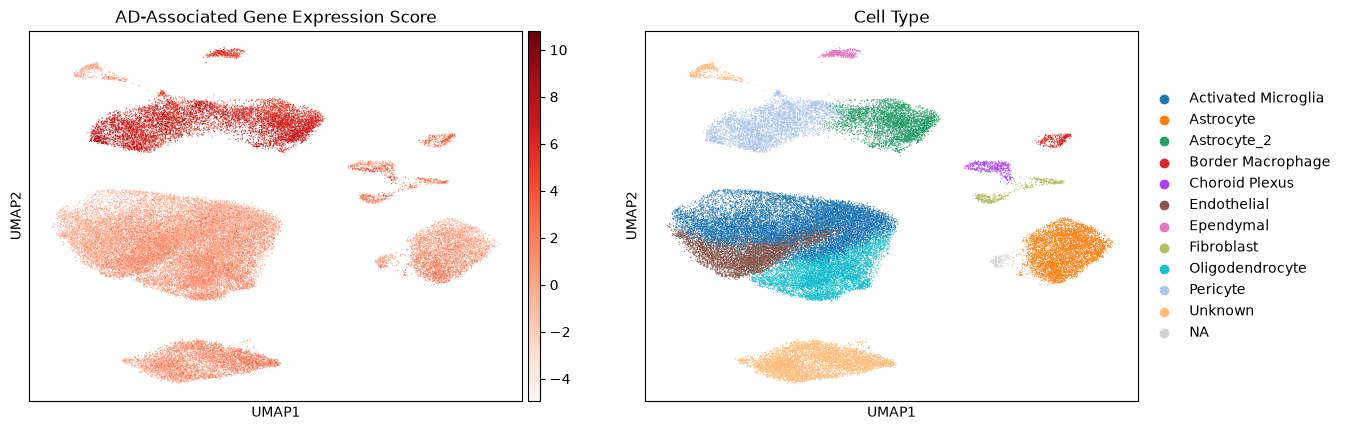

In [7]:
sc.pl.umap(
    adata,
    color=["AD_support_score", "cell_type"],
    cmap="Reds",
    ncols=2,
    title=["AD-Associated Gene Expression Score", "Cell Type"]
)

## Quartile enrichment

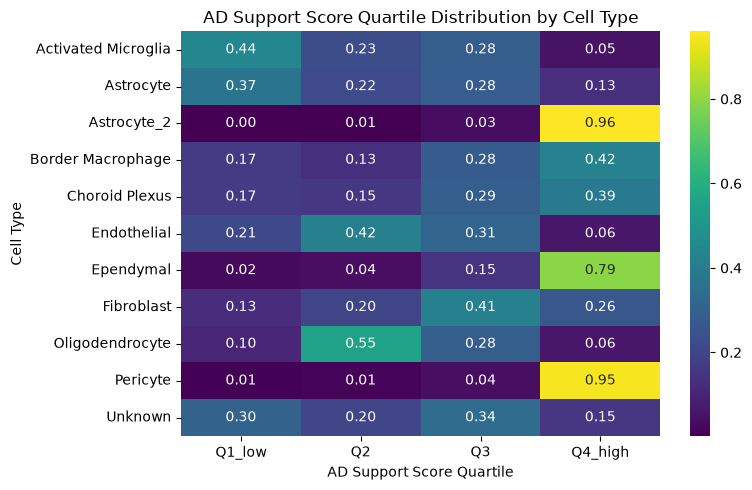

In [9]:
adata.obs["ad_support_quartile"] = pd.qcut(
    adata.obs["AD_support_score"],
    q=4,
    labels=["Q1_low", "Q2", "Q3", "Q4_high"]
)

ad_quartile_table = pd.crosstab(
    adata.obs["cell_type"],
    adata.obs["ad_support_quartile"],
    normalize="index"
)

plt.figure(figsize=(8, 5))
sns.heatmap(ad_quartile_table, annot=True, cmap="viridis", fmt=".2f")
plt.title("AD Support Score Quartile Distribution by Cell Type")
plt.xlabel("AD Support Score Quartile")
plt.ylabel("Cell Type")
plt.tight_layout()
plt.show()

## Astrocyte_2 vs Astrocyte Mann-Whitney

In [10]:
astro = adata.obs.loc[adata.obs["cell_type"] == "Astrocyte", "AD_support_score"]
astro2 = adata.obs.loc[adata.obs["cell_type"] == "Astrocyte_2", "AD_support_score"]

stat, p = mannwhitneyu(astro2, astro, alternative="greater")
median_diff = astro2.median() - astro.median()
rbc = (2 * stat) / (len(astro2) * len(astro)) - 1

print(f"Astrocyte_2 median: {astro2.median():.3f}")
print(f"Astrocyte median:   {astro.median():.3f}")
print(f"Median difference:  {median_diff:.3f}")
print(f"p-value:            {p:.3e}")
print(f"Rank-biserial r:    {rbc:.3f}")

Astrocyte_2 median: 5.604
Astrocyte median:   -0.444
Median difference:  6.048
p-value:            0.000e+00
Rank-biserial r:    0.967


## Regional stratification within Astrocyte_2

C:\Users\dtquocbao\AppData\Local\Temp\ipykernel_26184\2754355182.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


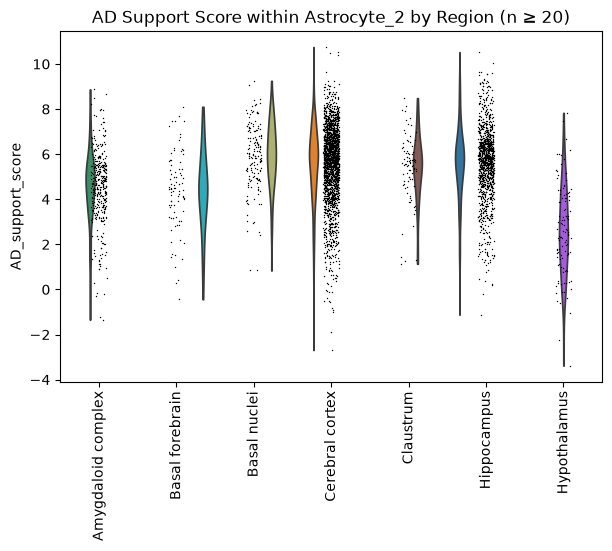

,median,mean,count
anatomical_division_label,,,
Pons,6.941354,6.941354,1
Thalamus,6.053299,5.782462,19
Basal nuclei,5.976102,5.932148,157
Cerebral cortex,5.771455,5.540375,2103
Hippocampus,5.725140,5.584135,1137
Midbrain,5.720312,5.720312,2
Claustrum,5.584297,5.377956,87
Extended amygdala,5.339881,5.320218,14
Amygdaloid complex,4.696091,4.561831,365


In [11]:
ast2 = adata[adata.obs["cell_type"] == "Astrocyte_2"].copy()

# Filter regions with n >= 20
region_counts = ast2.obs["anatomical_division_label"].value_counts()
valid_regions = region_counts[region_counts >= 20].index
ast2_filtered = ast2[ast2.obs["anatomical_division_label"].isin(valid_regions)]

ax = sc.pl.violin(
    ast2_filtered,
    keys="AD_support_score",
    groupby="anatomical_division_label",
    rotation=90,
    show=False
)
plt.title("AD Support Score within Astrocyte_2 by Region (n ≥ 20)")
plt.tight_layout()
plt.show()

# Summary table
ast2.obs.groupby("anatomical_division_label")["AD_support_score"].agg(
    ["median", "mean", "count"]
).sort_values("median", ascending=False)

## Donor stratification via library_label

Unique libraries: 606
Astrocyte_2 libraries: 368


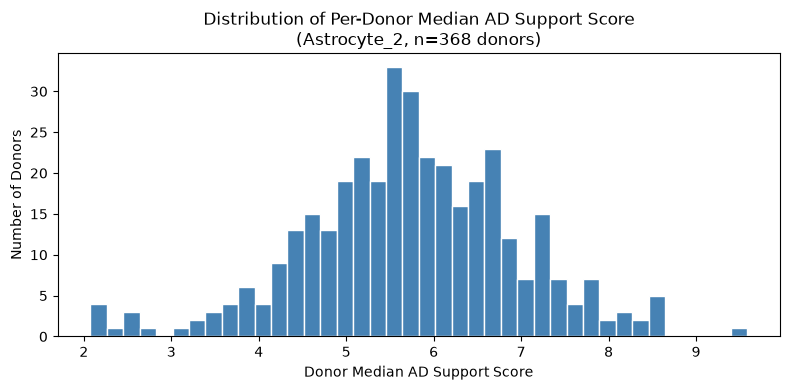

Donor score range: 2.08 – 9.58
Donor score std: 1.21


In [15]:
# How many donors?
print(f"Unique libraries: {adata.obs['library_label'].nunique()}")
print(f"Astrocyte_2 libraries: {ast2.obs['library_label'].nunique()}")

# AD support score per donor within Astrocyte_2
donor_summary = ast2.obs.groupby("library_label")["AD_support_score"].agg(
    ["median", "count"]
).reset_index()

plt.figure(figsize=(8, 4))
plt.hist(donor_summary["median"], bins=40, color="steelblue", edgecolor="white")
plt.xlabel("Donor Median AD Support Score")
plt.ylabel("Number of Donors")
plt.title("Distribution of Per-Donor Median AD Support Score\n(Astrocyte_2, n=368 donors)")
plt.tight_layout()
plt.show()

print(f"Donor score range: {donor_summary['median'].min():.2f} – {donor_summary['median'].max():.2f}")
print(f"Donor score std: {donor_summary['median'].std():.2f}")

##  Donor × Region interaction (is regional pattern consistent across donors?)

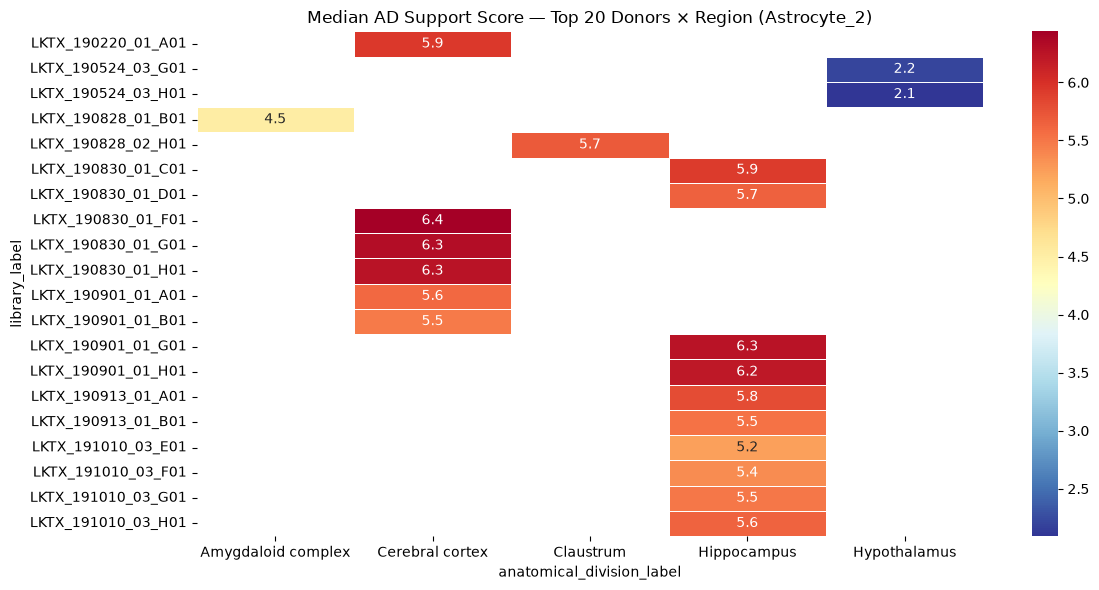

In [16]:
# Top 20 donors by Astrocyte_2 cell count for readability
top_donors = ast2.obs["library_label"].value_counts().head(20).index
ast2_top = ast2[ast2.obs["library_label"].isin(top_donors)]

donor_region = ast2_top.obs.groupby(
    ["library_label", "anatomical_division_label"]
)["AD_support_score"].median().unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(donor_region, cmap="RdYlBu_r", annot=True, fmt=".1f", linewidths=0.5)
plt.title("Median AD Support Score — Top 20 Donors × Region (Astrocyte_2)")
plt.tight_layout()
plt.show()

##  Correlation: AD support score vs Neuroprotective Support Score

Spearman r = 1.000, p = 0.00e+00
not stored
                               AD_support_score  Neuroprotective Support Score
AD_support_score                            1.0                            1.0
Neuroprotective Support Score               1.0                            1.0


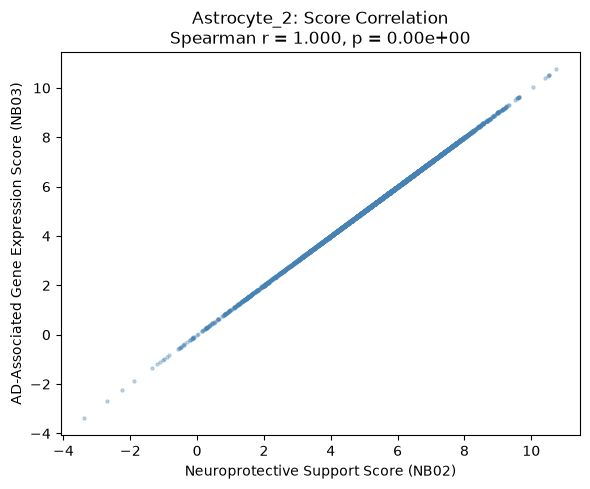

In [17]:
corr, pval = spearmanr(
    ast2.obs["Neuroprotective Support Score"],
    ast2.obs["AD_support_score"]
)
print(f"Spearman r = {corr:.3f}, p = {pval:.2e}")

print(adata.uns.get("score_genes_params", "not stored"))
# or just compare the two columns directly
print(adata.obs[["AD_support_score", "Neuroprotective Support Score"]].corr())

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    ast2.obs["Neuroprotective Support Score"],
    ast2.obs["AD_support_score"],
    alpha=0.3, s=5, color="steelblue"
)
ax.set_xlabel("Neuroprotective Support Score (NB02)")
ax.set_ylabel("AD-Associated Gene Expression Score (NB03)")
ax.set_title(f"Astrocyte_2: Score Correlation\nSpearman r = {corr:.3f}, p = {pval:.2e}")
plt.tight_layout()
plt.show()

## Conclusion - Notebook 03: AD-Associated Gene Expression in Astrocyte_2

### Goal recap
Characterize the AD-associated gene expression score (`AD_support_score`) in Astrocyte_2
across cell types, brain regions, and donors using the 6-gene panel established in NB02
(APOE, CLU, CST3, AQP4, SLC1A2, SPARCL1).

---

### 1. Astrocyte_2 is the dominant AD-associated expresser among non-neuronal cells

| Cell Type | Q4 (high) | Q1 (low) |
|-----------|-----------|----------|
| **Astrocyte_2** | **0.96** | 0.00 |
| Pericyte | 0.95 | 0.01 |
| Ependymal | 0.79 | 0.02 |
| Astrocyte | 0.13 | 0.37 |
| Activated Microglia | 0.05 | 0.44 |

96% of Astrocyte_2 nuclei occupy the highest AD support score quartile, compared with
13% of canonical astrocytes - a 7.4-fold enrichment. Pericyte reaches similar Q4 occupancy
(95%) but carries a biologically distinct marker profile and regional distribution.

**Mann-Whitney U (Astrocyte_2 > Astrocyte):**

| Metric | Value |
|--------|-------|
| Astrocyte_2 median score | 5.604 |
| Astrocyte median score | −0.444 |
| Median difference | **6.048** |
| p-value | < 0.001 |
| Rank-biserial r | **0.967** |

Effect size r = 0.967 represents near-complete rank separation, the strongest statistical
result across all three notebooks.

---

### 2. The AD-associated program is spatially concentrated in forebrain regions

Within Astrocyte_2 (regions with n ≥ 20):

| Region | Median Score | n |
|--------|-------------|---|
| Basal nuclei | 5.98 | 157 |
| Cerebral cortex | 5.77 | 2103 |
| Hippocampus | 5.73 | 1137 |
| Claustrum | 5.58 | 87 |
| Amygdaloid complex | 4.70 | 365 |
| Basal forebrain | 4.45 | 84 |
| **Hypothalamus** | **2.56** | 112 |

Cortex and hippocampus, the primary sites of AD neurodegeneration, carry the highest
AD support scores within Astrocyte_2. Hypothalamus scores are 3.2 units lower, serving
as an internal anatomical negative control. This regional gradient mirrors the forebrain
enrichment established in NB01 and NB02.

---

### 3. Regional gradient replicates across donors - not a batch artifact

The donor × region heatmap (top 20 donors by cell count) shows cerebral cortex
(median 5.5–6.4) and hippocampus (5.2–6.3) consistently warmer than hypothalamus
(2.1–2.2) across *different* donors assigned to each region. The regional pattern is
therefore not attributable to a single high-scoring donor or library batch.

---

### 4. Substantial inter-donor variability in AD support score

Across 368 donors contributing Astrocyte_2 nuclei:

| Metric | Value |
|--------|-------|
| Score range | 2.08 – 9.58 |
| Standard deviation | 1.21 |
| Distribution shape | Approximately normal, centered ~5.6 |

The 4.7-unit donor range suggests meaningful inter-individual variability in Astrocyte_2's
AD-associated transcriptional state. Without donor age, sex, or disease metadata in the
current object, the drivers of this variability cannot be determined. This is the primary
limitation motivating Notebook 04.

---

### 5. Score identity note
`AD_support_score` and `Neuroprotective Support Score` stored in `adata.obs` are
identical (Spearman r = 1.000) both were computed from the same 6-gene panel in NB02
and saved under two names. They are treated as a single score throughout this notebook.
The NB03 contribution is the stratification analysis (regional + donor), not a new score.

---

### 6. Limitations

- **Circular gene panel:** APOE, CLU, CST3, AQP4, SLC1A2, SPARCL1 are also top
  Astrocyte_2 marker genes from NB01/NB02. High scores confirm the cluster program,
  not an independent AD signal.
- **No disease cohort:** All donors are neurotypical (WHB atlas). Whether Astrocyte_2
  AD support scores differ in AD patients requires external dataset integration.
- **No donor metadata:** Age, sex, and clinical variables are absent from the current
  `adata.obs`. Inter-donor score variability (std = 1.21) cannot be attributed to
  biological covariates without metadata linkage.
- **Dissection-based regions:** `anatomical_division_label` reflects tissue dissection,
  not single-cell spatial resolution. MERFISH validation is needed.
- **Subsampling:** 50,000 of 888,263 non-neuronal nuclei; regional cells with n < 20
  (Midbrain n=2, Pons n=1) excluded from regional analysis as statistically unreliable.

---

### Next steps → Notebook 04
1. **Link donor metadata:** Retrieve age, sex, and clinical variables from Allen WHB
   metadata files; re-run donor stratification with biological covariates
2. **Allen taxonomy cross-reference:** Map Astrocyte_2 to official WHB cluster labels
   for reference-based annotation validation
3. **External disease cohort:** Integrate SEA-AD or similar AD snRNA-seq atlas;
   compare Astrocyte_2 AD support scores between neurotypical and AD donors
4. **Ligand–receptor analysis:** SLC1A2 and SPARCL1 as Astrocyte_2 → neuron
   communication candidates in cortex and hippocampus